In [ ]:
%pip install pandas numpy matplotlib seaborn jupyter

Could not fetch URL https://pypi.org/simple/pip/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/pip/ (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1000)'))) - skipping
Note: you may need to restart the kernel to use updated packages.


### Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint

# Загрузка данных
df = pd.read_csv('../data/sleep_study_1000.csv')  # Путь к файлу
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 1000 строк, 15 столбцов


,ID,Age,Gender,Bedtime,WakeupTime,SleepDuration,SleepEfficiency,REMSleepPercentage,DeepSleepPercentage,LightSleepPercentage,Awakenings,CaffeineConsumption,AlcoholConsumption,SmokingStatus,ExerciseFrequency
0,1,80,Female,2025-09-30 07:32:17,2025-09-30 13:49:16.669051,6.283241,0.57,15,35,50,0,25.0,1,Yes,1
1,2,24,Male,2025-06-29 20:59:50,2025-06-30 04:09:10.207162,7.155613,0.91,29,68,3,4,50.0,0,No,2
2,3,37,Male,2025-12-24 21:28:32,2025-12-25 03:31:34.257053,6.050627,0.58,15,35,50,3,50.0,0,No,5
3,4,68,Female,2025-02-22 00:25:33,2025-02-22 07:26:37.046703,7.017791,0.88,28,44,28,1,50.0,0,Yes,4
4,5,58,Male,2025-09-02 12:31:53,2025-09-02 21:17:46.256228,8.764793,0.95,28,40,32,4,25.0,4,No,4


### 1.1 Типы шкал 
ID - Абсолютная  
Age - Шкала отношений  
Gender - Номинальная   
Bedtime - Интервальная   
WakeupTime - Интервальная   
SleepDuration - Шкала отношений   
SleepEfficiency - Шкала отношений   
REMSleepPercentage - Шкала отношений   
DeepSleepPercentage - Шкала отношений    
LightSleepPercentage - Шкала отношений    
Awakenings - Порядковая    
CaffeineConsumption - Шкала отношений    
SmokingStatus - Номинальная    
ExerciseFrequency - Шкала отношений     

### 1.2 Сравнение признаков: SmokingsStatus (Номинальная) и SleepEfficiency (Отношений)

In [ ]:
stats_SmokingStatus = {
    "Среднее": "Ошибка (не применимо)",
    "Медиана": "Ошибка (не применимо)",
    "Мода": df['SmokingStatus'].mode()[0]
}

stats_SleepEfficiency = {
    "Среднее": df['SleepEfficiency'].mean(),
    "Медиана": df['SleepEfficiency'].median(),
    "Мода": df['SleepEfficiency'].mode()[0]
}

print(f"Статистики Price: {stats_SmokingStatus}")
print(f"Статистики Model: {stats_SleepEfficiency}")

# Категориальные
print(df['SmokingStatus'].describe())

# Числовые
print(df['SleepEfficiency'].describe())

Статистики Price: {'Среднее': 'Ошибка (не применимо)', 'Медиана': 'Ошибка (не применимо)', 'Мода': 'Yes'}
Статистики Model: {'Среднее': 0.7201500000000001, 'Медиана': 0.72, 'Мода': 0.55}
count     1000
unique       2
top        Yes
freq       513
Name: SmokingStatus, dtype: object
count    1000.000000
mean        0.720150
std         0.128139
min         0.500000
25%         0.610000
50%         0.720000
75%         0.830000
max         0.950000
Name: SleepEfficiency, dtype: float64


Для номинальных признаков корректны только частоты и мода. Для признаков шкалы отношений допустимы все меры центральной тенденции. Pandas позволяет вычислить среднее для строк (object), но результат будет бессмысленным (например, 'Male' + 'Female' / 2).

### 2. Диагностика типа пропусков


### 3. Индикатор пропуска
1.  Объясните, в каком случае сам факт пропуска несёт информацию.     
Когда пропуск систематически связан с поведением или состоянием (например, больные реже заполняют опросники → пропуск = маркер тяжести состояния).
2. Почему значимость индикатора в модели - это сигнал о неправильной или грубой
импутации?   
Если после импутации индикатор остаётся значимым в модели — значит, импутация не восстановила истинную зависимость, и информация о пропуске всё ещё несёт уникальный сигнал.
3. Приведите пример признака, для которого индикатор пропуска:   
Полезен: пропуск в доходе при анализе финансового поведения (часто = низкий доход).
Бесполезен: пропуск в случайно сгенерированном ID.       
Опасен: пропуск в диагнозе — может ввести в заблуждение, если интерпретировать как «здоров».   

### 4. Выброс - это ошибка или сигнал?

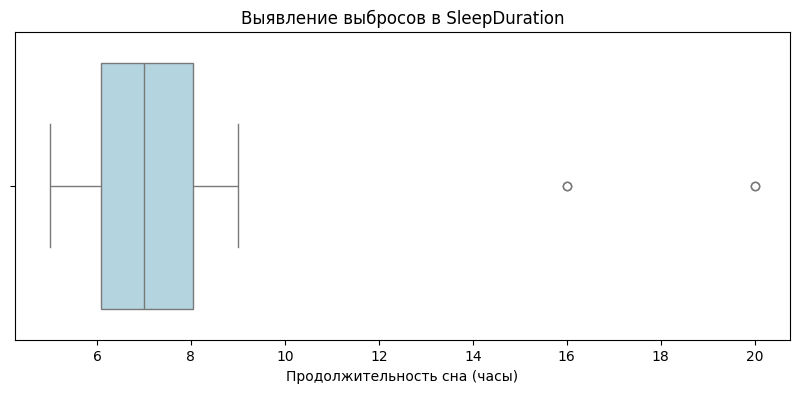

In [2]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['SleepDuration'], color='lightblue')
plt.title("Выявление выбросов в SleepDuration")
plt.xlabel("Продолжительность сна (часы)")
plt.show()